In [10]:
import pandas as pd                                            #to read exel
import numpy as np                                             #for statistic
import matplotlib.pyplot as plt                                #for plot
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, pearsonr, spearmanr, chi2_contingency, fisher_exact
#for statistic, shapiro for normality, levene for var
# =========================
# 1) Load data
# =========================
df = pd.read_excel(r"C:\kar\matlab\subsub.xlsx")              #read exel and save in df variable
df["class"] = df["class"].str.strip().str.title()             # turn low labels to Low

print("===== DATA LOADED =====")
print(df.head())                                             #show the first five lines of the data


===== DATA LOADED =====
       Code  FSIQ    class  VIQ  PIQ Gender  Age  Education Level   \
0  CBM00011   101  Average  101  102      F   22       High School   
1  CBM00214    92      Low   91   95      M   29       High School   
2  CBM00163    94      Low   83  106      M   22       High School   
3  CBM00207    97  Average   95  100      F   39  Secondary School   
4  CBM00074   111  Average  108  114      M   24       High School   

  Hand preference  
0           Right  
1           Right  
2           Right  
3           Right  
4           Right  


In [25]:
# =========================
# 2) Basic checks
# =========================
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe(include="all"))       #for nums: max, count, mean.. fortext unique, top, freq

# Optional outlier check
print("\n===== OUTLIER CHECK: FSIQ =====")
q1 = df["FSIQ"].quantile(0.25)
q3 = df["FSIQ"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr               #boundaries of outliers
upper = q3 + 1.5 * iqr
outliers = df[(df["FSIQ"] < lower) | (df["FSIQ"] > upper)]
print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
print(f"Number of outliers: {len(outliers)}")


===== DESCRIPTIVE STATISTICS =====
            Code        FSIQ    class         VIQ         PIQ Gender  \
count         81   81.000000       81   81.000000   81.000000     81   
unique        81         NaN        3         NaN         NaN      2   
top     CBM00011         NaN  Average         NaN         NaN      M   
freq           1         NaN       35         NaN         NaN     61   
mean         NaN  102.913580      NaN   98.111111  108.469136    NaN   
std          NaN   13.622773      NaN   14.085453   12.026103    NaN   
min          NaN   71.000000      NaN   71.000000   82.000000    NaN   
25%          NaN   93.000000      NaN   86.000000  101.000000    NaN   
50%          NaN  103.000000      NaN   99.000000  107.000000    NaN   
75%          NaN  112.000000      NaN  109.000000  118.000000    NaN   
max          NaN  135.000000      NaN  128.000000  130.000000    NaN   

              Age Education Level  Hand preference  
count   81.000000               81            

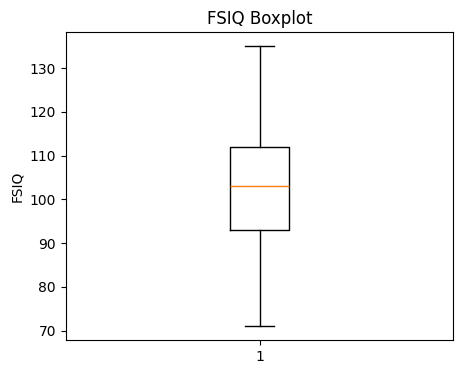

In [21]:
# Boxplot
plt.figure(figsize=(5, 4))                       #the size of the pic
plt.boxplot(df["FSIQ"].dropna())                 #and drop the nan
plt.title("FSIQ Boxplot")
plt.ylabel("FSIQ")
plt.show()


(array([ 3.,  4.,  6., 13., 13., 15., 11., 10.,  4.,  2.]),
 array([ 71. ,  77.4,  83.8,  90.2,  96.6, 103. , 109.4, 115.8, 122.2,
        128.6, 135. ]),
 <BarContainer object of 10 artists>)

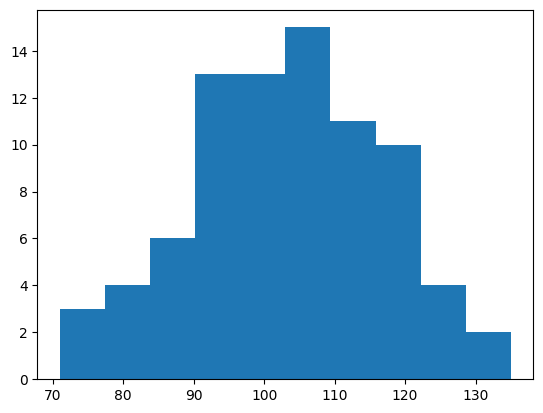

In [24]:
plt.hist(df["FSIQ"], bins=10)

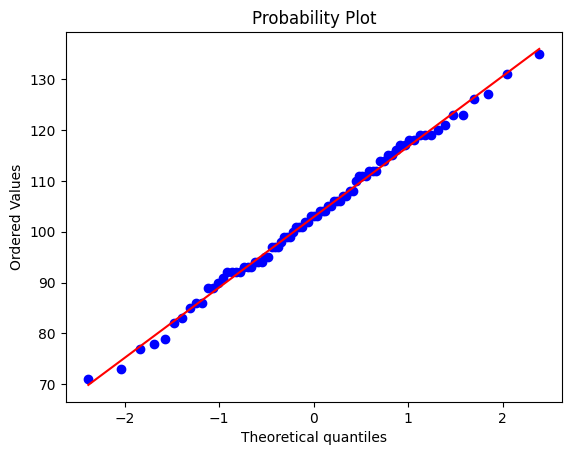

In [22]:
from scipy.stats import probplot

probplot(df["FSIQ"].dropna(), dist="norm", plot=plt)                #to show normality
plt.show()

['Average' 'Low' 'High']


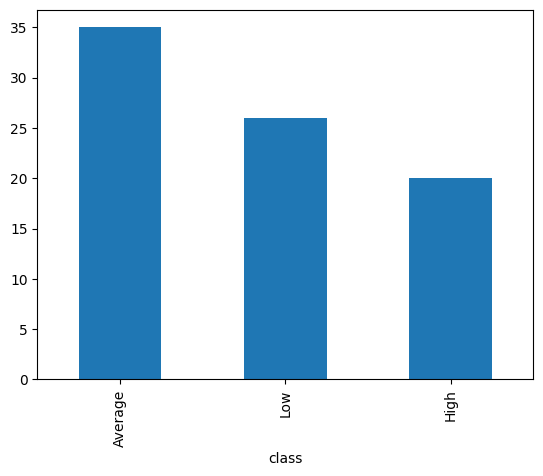

In [11]:
df["class"].value_counts().plot(kind="bar")
print(df["class"].unique())


<Axes: ylabel='count'>

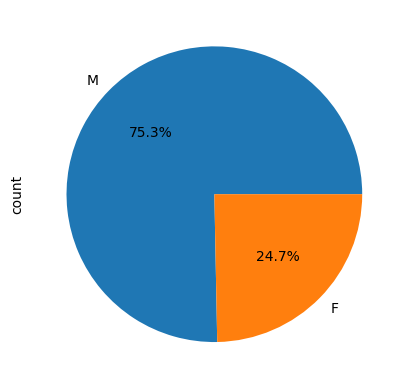

In [13]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")

C:\Users\shab\AppData\Local\Temp\ipykernel_3680\3112350243.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male, female], labels=["Male","Female"])


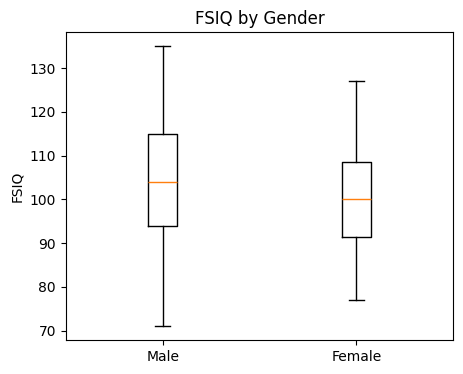

In [27]:
tmp = df[["Gender", "FSIQ"]].dropna()
male = tmp[tmp["Gender"] == "M"]["FSIQ"]
female = tmp[tmp["Gender"] == "F"]["FSIQ"]

plt.figure(figsize=(5,4))
plt.boxplot([male, female], labels=["Male","Female"])
plt.title("FSIQ by Gender")
plt.ylabel("FSIQ")
plt.show()

In [15]:
print("\n===== MISSING VALUES =====")
print(df.isna().sum())


===== MISSING VALUES =====
Code                0
FSIQ                0
class               0
VIQ                 0
PIQ                 0
Gender              0
Age                 0
Education Level     0
Hand preference     0
dtype: int64


In [16]:
# =========================
def cohens_d(x, y):        # this function shows how big is the difference between 2 gps. make a function named cohens that has 2 groups input
    x = np.asarray(x)      # turn data into array
    y = np.asarray(y)
    nx, ny = len(x), len(y)    #how many people in each gp
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)     #each gps var
    pooled_sd = np.sqrt(((nx - 1) * sx + (ny - 1) * sy) / (nx + ny - 2))   #Standard Deviation
    return (np.mean(x) - np.mean(y)) / pooled_sd if pooled_sd != 0 else np.nan

def normality_result(x):
    x = pd.Series(x).dropna()    #turn daa into series and drop the nan
    if len(x) < 3:               # if there are less than 3 datas, cant use shapiro
        return None, None
    if len(x) > 5000:
        return "too_large", "Use QQ plot or KS test"
    w, p = shapiro(x)
    return w, p

def print_norm(label, x):
    w, p = normality_result(x)
    if w is None:
        print(f"{label}: Not enough data for Shapiro test.")
        print("Sample size is too small for normality testing.")
    elif w == "too_large":
        print(f"{label}: Sample size too large for Shapiro.")
        print(" Use QQ plot or Kolmogorov-Smirnov test instead.")
    else:
        print(f"{label}: W={w}, p={p}")
        if p > 0.05:
            print(" Data are approximately normally distributed.")
        else:
            print(" Data are not normally distributed.")


In [17]:
# =========================
# 3) Gender vs FSIQ
# =========================
print("\n===== GENDER VS FSIQ =====")
tmp = df[["Gender", "FSIQ"]].dropna()
male = tmp[tmp["Gender"] == "M"]["FSIQ"]
female = tmp[tmp["Gender"] == "F"]["FSIQ"]

print_norm("Male FSIQ", male)
print_norm("Female FSIQ", female)

male_w, male_p = normality_result(male)
female_w, female_p = normality_result(female)
#next line shows if the result for shapiro is ok go to t test
if isinstance(male_w, float) and isinstance(female_w, float) and male_p > 0.05 and female_p > 0.05:
    stat_lev, p_lev = levene(male, female)    #are VARs the same
    print(f"Levene test: stat={stat_lev}, p={p_lev}")
    if p_lev > 0.05:
        t, p = ttest_ind(male, female, equal_var=True)
        print(f"Independent t-test: t={t}, p={p}")
        print(f"Cohen's d: {cohens_d(male, female)}")
        if p < 0.05:
            print("There is a statistically significant difference between males and females.")
        else:
            print("There is no statistically significant difference between males and females.")
    else:              #VARs are not the same
        t, p = ttest_ind(male, female, equal_var=False)
        print(f"Welch's t-test: t={t}, p={p}")
        print(f"Cohen's d: {cohens_d(male, female)}")
        if p < 0.05:
            print("There is a statistically significant difference between males and females.")
        else:
            print("There is no statistically significant difference between males and females.")
else:              #if data is not normal
    u, p = mannwhitneyu(male, female, alternative="two-sided")
    print(f"Mann-Whitney U: U={u}, p={p}")
    if p < 0.05:
        print("There is a statistically significant difference between males and females.")
    else:
        print("There is no statistically significant difference between males and females.")
    print("Because normality was not met, Mann-Whitney U test was used.")



===== GENDER VS FSIQ =====
Male FSIQ: W=0.9905240511458128, p=0.919655752411001
 Data are approximately normally distributed.
Female FSIQ: W=0.9864947931661502, p=0.9892300534504351
 Data are approximately normally distributed.
Levene test: stat=0.054501298423836594, p=0.8160118754930558
Independent t-test: t=0.9885556783748582, p=0.32589872228532113
Cohen's d: 0.254720400666282
There is no statistically significant difference between males and females.


In [18]:
# =========================
# 4) Age vs FSIQ correlation
# =========================
print("\n===== AGE VS FSIQ CORRELATION =====")
corr_df = df[["Age", "FSIQ"]].dropna()

print_norm("Age", corr_df["Age"])     #are these normal
print_norm("FSIQ", corr_df["FSIQ"])

age_w, age_p = normality_result(corr_df["Age"])
fsiq_w, fsiq_p = normality_result(corr_df["FSIQ"])
#next line shows if shapiro is number and not nan or data too large
if isinstance(age_w, float) and isinstance(fsiq_w, float) and age_p > 0.05 and fsiq_p > 0.05:
    r, p = pearsonr(corr_df["Age"], corr_df["FSIQ"])
    print(f"Pearson correlation: r={r}, p={p}")
    if p < 0.05:
        print("There is a statistically significant linear relationship between Age and FSIQ.")
    else:
        print("There is no statistically significant linear relationship between Age and FSIQ.")
else:        #data is not normal
    r, p = spearmanr(corr_df["Age"], corr_df["FSIQ"])
    print(f"Spearman correlation: rho={r}, p={p}")
    if p < 0.05:
        print("There is a statistically significant monotonic relationship between Age and FSIQ.")
    else:
        print("There is no statistically significant monotonic relationship between Age and FSIQ.")
    print("Because normality was not met, Spearman correlation was used.")


===== AGE VS FSIQ CORRELATION =====
Age: W=0.9732493798974086, p=0.08774571276080378
 Data are approximately normally distributed.
FSIQ: W=0.9939054795030853, p=0.9705198497659043
 Data are approximately normally distributed.
Pearson correlation: r=-0.12764249664033447, p=0.2561326505342949
There is no statistically significant linear relationship between Age and FSIQ.


In [19]:
# =========================
# 5) Chi-square: Gender vs IQ group
# =========================
print("\n===== CHI-SQUARE: GENDER VS IQ GROUP =====")
chi_df = df[["Gender", "FSIQ"]].dropna().copy()
median_fsiq = chi_df["FSIQ"].median()
chi_df["IQ_Group"] = np.where(chi_df["FSIQ"] < median_fsiq, "Low", "High")

table = pd.crosstab(chi_df["Gender"], chi_df["IQ_Group"])    #table to show how many peole in each gp, male high, fe high...
print("Contingency table:")
print(table)

chi2, p, dof, expected = chi2_contingency(table)    #dof is degree of freedom
print("\nExpected frequencies:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

low_expected = (expected < 5).sum()
print(f"Cells with expected frequency < 5: {low_expected}")

if low_expected == 0:
    print(f"Chi-square test: chi2={chi2}, p={p}, dof={dof}")
    n = table.to_numpy().sum()
    r, c = table.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r - 1, c - 1))))
    print(f"Cramer's V: {cramers_v}")
    if p < 0.05:
        print("There is a statistically significant association between Gender and IQ group.")
    else:
        print("There is no statistically significant association between Gender and IQ group.")
else:
    if table.shape == (2, 2):
        oddsratio, p = fisher_exact(table)
        print(f"Fisher's exact test: odds ratio={oddsratio}, p={p}")
        if p < 0.05:
            print("There is a statistically significant association between Gender and IQ group.")
        else:
            print("There is no statistically significant association between Gender and IQ group.")
        print("Fisher's exact test was used because expected counts were too small.")
    else:
        print("Chi-square assumptions were violated because some expected frequencies were below 5.")



===== CHI-SQUARE: GENDER VS IQ GROUP =====
Contingency table:
IQ_Group  High  Low
Gender             
F            9   11
M           33   28

Expected frequencies:
IQ_Group      High       Low
Gender                      
F         10.37037   9.62963
M         31.62963  29.37037
Cells with expected frequency < 5: 0
Chi-square test: chi2=0.20146032246442075, p=0.6535446889077403, dof=1
Cramer's V: 0.049871479573694144
There is no statistically significant association between Gender and IQ group.


In [65]:
#Gender vs IQ Group (Low vs High only from the data excel itself)
# =========================
# 5) Chi-square: Gender vs IQ group
# =========================
print("\n===== CHI-SQUARE: GENDER VS IQ GROUP =====")

chi_df = df[["Gender", "class"]].dropna().copy()


# Keep only Low and High groups
chi_df = chi_df[chi_df["class"].isin(["Low", "High"])]

print("\nGroups included in the analysis:")
print(chi_df["class"].unique())

print("\nNumber of participants in each IQ group:")
print(chi_df["class"].value_counts())

print("\nNumber of participants by Gender:")
print(chi_df["Gender"].value_counts())

table = pd.crosstab(chi_df["Gender"], chi_df["class"])

print("Contingency table:")
print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("\nExpected frequencies:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

low_expected = (expected < 5).sum()

print(f"Cells with expected frequency < 5: {low_expected}")



if low_expected == 0:

    print(f"Chi-square test: chi2={chi2}, p={p}, dof={dof}")

    n = table.to_numpy().sum()
    r, c = table.shape

    cramers_v = np.sqrt(
        chi2 /
        (n * (min(r - 1, c - 1)))
    )

    print(f"Cramer's V: {cramers_v}")

    if p < 0.05:
        print("There is a statistically significant association between Gender and IQ group.")
    else:
        print("There is no statistically significant association between Gender and IQ group.")

else:

    if table.shape == (2,2):

        oddsratio, p = fisher_exact(table)

        print(f"Fisher's exact test: odds ratio={oddsratio}, p={p}")

        if p < 0.05:
            print("There is a statistically significant association between Gender and IQ group.")
        else:
            print("There is no statistically significant association between Gender and IQ group.")

        print("Fisher's exact test was used because expected counts were too small.")

    else:

        print("Chi-square assumptions were violated because expected frequencies were below 5.")


===== CHI-SQUARE: GENDER VS IQ GROUP =====

Groups included in the analysis:
['Low' 'High']

Number of participants in each IQ group:
class
Low     26
High    20
Name: count, dtype: int64

Number of participants by Gender:
Gender
M    36
F    10
Name: count, dtype: int64
Contingency table:
class   High  Low
Gender           
F          3    7
M         17   19

Expected frequencies:
class        High        Low
Gender                      
F        4.347826   5.652174
M       15.652174  20.347826
Cells with expected frequency < 5: 1
Fisher's exact test: odds ratio=0.4789915966386555, p=0.4761693060048138
There is no statistically significant association between Gender and IQ group.
Fisher's exact test was used because expected counts were too small.


In [53]:
# =========================
# 6) Age vs IQ group
# =========================
print("\n===== AGE VS IQ GROUP =====")
age_df = df[["Age", "FSIQ"]].dropna().copy()
median_fsiq = age_df["FSIQ"].median()
age_df["IQ_Group"] = np.where(age_df["FSIQ"] < median_fsiq, "Low", "High")

low_age = age_df[age_df["IQ_Group"] == "Low"]["Age"]
high_age = age_df[age_df["IQ_Group"] == "High"]["Age"]

print_norm("Low IQ Age", low_age)
print_norm("High IQ Age", high_age)

low_w, low_p = normality_result(low_age)
high_w, high_p = normality_result(high_age)

if isinstance(low_w, float) and isinstance(high_w, float) and low_p > 0.05 and high_p > 0.05:
    stat_lev, p_lev = levene(low_age, high_age)
    print(f"Levene test: stat={stat_lev}, p={p_lev}")
    if p_lev > 0.05:
        t, p = ttest_ind(low_age, high_age, equal_var=True)
        print(f"Independent t-test: t={t}, p={p}")
    else:
        t, p = ttest_ind(low_age, high_age, equal_var=False)
        print(f"Welch's t-test: t={t}, p={p}")
    print(f"Cohen's d: {cohens_d(low_age, high_age)}")
    if p < 0.05:
        print("There is a statistically significant difference in Age between Low and High IQ groups.")
    else:
        print("There is no statistically significant difference in Age between Low and High IQ groups.")
else:
    u, p = mannwhitneyu(low_age, high_age, alternative="two-sided")
    print(f"Mann-Whitney U: U={u}, p={p}")
    if p < 0.05:
        print("There is a statistically significant difference in Age between Low and High IQ groups.")
    else:
        print("There is no statistically significant difference in Age between Low and High IQ groups.")
    print("Because normality was not met, Mann-Whitney U test was used.")


===== AGE VS IQ GROUP =====
Low IQ Age: W=0.9550359289732016, p=0.12149703259259231
 Data are approximately normally distributed.
High IQ Age: W=0.9762410283459187, p=0.5211539117416022
 Data are approximately normally distributed.
Levene test: stat=0.05272068893256838, p=0.8189883913216889
Independent t-test: t=0.7477596185901856, p=0.45682530726492054
Cohen's d: 0.16628289189202222
There is no statistically significant difference in Age between Low and High IQ groups.


In [64]:
#Age vs IQ Group (Low vs High only from the data excel itself)
# =========================
# 6) Age vs IQ group
# =========================
print("\n===== AGE VS IQ GROUP =====")

age_df = df[["Age", "class"]].dropna().copy()


# Keep only Low and High groups
age_df = age_df[age_df["class"].isin(["Low", "High"])]

print("\nGroups included in the analysis:")
print(age_df["class"].unique())

print("\nNumber of participants in each group:")
print(age_df["class"].value_counts())

low_age = age_df[age_df["class"] == "Low"]["Age"]
high_age = age_df[age_df["class"] == "High"]["Age"]

print_norm("Low IQ Age", low_age)
print_norm("High IQ Age", high_age)

low_w, low_p = normality_result(low_age)
high_w, high_p = normality_result(high_age)

if (
    isinstance(low_w, float)
    and isinstance(high_w, float)
    and low_p > 0.05
    and high_p > 0.05
):

    stat_lev, p_lev = levene(low_age, high_age)

    print(f"Levene test: stat={stat_lev}, p={p_lev}")

    if p_lev > 0.05:

        t, p = ttest_ind(low_age, high_age, equal_var=True)

        print(f"Independent t-test: t={t}, p={p}")

    else:

        t, p = ttest_ind(low_age, high_age, equal_var=False)

        print(f"Welch's t-test: t={t}, p={p}")

    print(f"Cohen's d: {cohens_d(low_age, high_age)}")

    if p < 0.05:
        print("There is a statistically significant difference in Age between Low and High IQ groups.")
    else:
        print("There is no statistically significant difference in Age between Low and High IQ groups.")

else:

    u, p = mannwhitneyu(
        low_age,
        high_age,
        alternative="two-sided"
    )

    print(f"Mann-Whitney U: U={u}, p={p}")

    if p < 0.05:
        print("There is a statistically significant difference in Age between Low and High IQ groups.")
    else:
        print("There is no statistically significant difference in Age between Low and High IQ groups.")

    print("Because normality was not met, Mann-Whitney U test was used.")


===== AGE VS IQ GROUP =====

Groups included in the analysis:
['Low' 'High']

Number of participants in each group:
class
Low     26
High    20
Name: count, dtype: int64
Low IQ Age: W=0.9532800165374792, p=0.27640135600288307
 Data are approximately normally distributed.
High IQ Age: W=0.9526078360184422, p=0.4084173207238398
 Data are approximately normally distributed.
Levene test: stat=0.24648598587624482, p=0.6220316937066133
Independent t-test: t=0.6665278690094586, p=0.508553835016754
Cohen's d: 0.19824194817119373
There is no statistically significant difference in Age between Low and High IQ groups.
